# AI for Chemistry — Week 10, Session B
## Mini-project hackathon: a fully worked reference example

**Course:** AI for Chemistry · **Session:** 10B (hands-on hackathon, 2.0 h) ·
**Runtime:** < 30 s, no GPU.

### No new material this session
Per `syllabus.md`, Session B is a **hackathon**: you work on your own
mini-project (assigned Week 06B, brief in
`assessments/mini-project-brief.md`), and this session's assessment *is* the
mini-project itself, not this notebook.

This notebook is instead a **fully worked reference example** — the same
pipeline you are building, applied end to end to a dataset already familiar
from Week 04A (BBBP, blood-brain-barrier penetration), hitting every required
element from the mini-project brief's checklist. Copy the pattern, not the
dataset, for your own project.

### Suggested timing (hackathon session, ~120 min)

| Section | Checklist item | Time |
|--------:|-----------------|-----:|
| 0 | Setup | 5 min |
| 1 | Data hygiene | 15 min |
| 2 | Two representations | 10 min |
| 3 | Baseline + models | 15 min |
| 4 | Two evaluation splits | 15 min |
| 5 | Error analysis | 15 min |
| 6 | A stated limitation | 10 min |
| — | *(the rest of the session: your own mini-project)* | ~55 min |

### Learning objectives
1. Recognise every required mini-project element as a technique already
   practised in this course, applied together in one place. *(LO1-LO8)*
2. Use this notebook as a structural template for your own mini-project. *(LO8)*

### Prerequisites — before this notebook you should be able to
- Weeks 02, 03B, 04: data hygiene, the leaderboard pattern, classification
  metrics, cluster splits, error analysis.
- Have read `assessments/mini-project-brief.md`.

### How to use this notebook (solo study)
This is the **solutions** notebook — a complete worked example. The
**student** version blanks the analysis code exactly like every other
session, so you can rehearse building this pipeline yourself before applying
it to your own chosen dataset.


---
## 0. Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import Descriptors, Draw, rdFingerprintGenerator
from rdkit.ML.Cluster import Butina
RDLogger.DisableLog("rdApp.*")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score, f1_score,
                              confusion_matrix)

SEED = 0xC0FFEE                     # reproducibility checklist item: one seed, used throughout
np.random.seed(SEED)

ROOT = Path.cwd()
while not (ROOT / "sources").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "sources" / "datasets"
FIGDIR = ROOT / "lectures" / "week-10_applications-pitfalls" / "slides" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

print("BBBP.csv", "OK" if (DATA / "BBBP.csv").is_file() else "MISSING")


BBBP.csv OK


### ✅ Check yourself — Section 0

Prints `Section 0 OK`.


In [2]:
# --- checkpoint (do not edit) ---
assert (DATA / "BBBP.csv").is_file()
print("Section 0 OK")


Section 0 OK


**Conceptual questions**


1. This notebook reuses BBBP, already seen in Week 04A. Why is that a
   reasonable choice for a *reference example*, even though your own
   mini-project should generally use a dataset not already used in class?


**Answers**


1. A worked reference example benefits from an already-familiar dataset — it
   lets you focus entirely on *how the pieces fit together* (the pipeline
   structure) rather than also learning a new dataset's quirks; your own
   mini-project should indeed pick something new (`assessments/mini-project-
   brief.md`), precisely so you practise that step too.


---
## 1. Data hygiene ✅ *(brief checklist item 1)*

Desalt (Week 04A), drop unparseable rows, deduplicate by canonical structure
(Week 02B). State how many rows were removed at each step.


In [3]:
def largest_fragment_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    frags = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=True)
    return Chem.MolToSmiles(max(frags, key=lambda m: m.GetNumAtoms()))

raw = pd.read_csv(DATA / "BBBP.csv")
n0 = len(raw)
raw["canonical_smiles"] = raw["smiles"].apply(largest_fragment_smiles)
bbbp = raw[raw["canonical_smiles"].notna()]
n1 = len(bbbp)
bbbp = bbbp.drop_duplicates("canonical_smiles").reset_index(drop=True)
n2 = len(bbbp)

print(f"rows: {n0} -> parse {n1} -> dedupe {n2}")
print("class balance:", bbbp["p_np"].value_counts(normalize=True).round(3).to_dict())


rows: 2050 -> parse 2039 -> dedupe 1966
class balance: {1: 0.761, 0: 0.239}


### ✅ Check yourself — Section 1

Prints `Section 1 OK`. Row counts strictly decrease through the cleaning steps; every canonical SMILES is unique.


In [4]:
# --- checkpoint (do not edit) ---
assert n0 > n1 >= n2 > 0
assert bbbp["canonical_smiles"].is_unique
print("Section 1 OK")


Section 1 OK


**Conceptual questions**


1. Why report the row count after *each* step rather than just the final
   total?


**Answers**


1. It lets a reader (or your future self) see *which* step is responsible
   for any data loss — a parsing failure and a duplicate-structure removal
   have very different implications for whether the remaining data is
   trustworthy, and collapsing them into one number would hide that.


---
## 2. Two representations ✅ *(checklist item 2)*

Descriptors (Week 02) and Morgan fingerprints (Week 02B) — chosen because
they sit at different points on Week 06's hand-engineered/learned spectrum,
letting Section 3 show whether that choice matters for *this* task.


In [5]:
DESCRIPTORS = {
    "MolWt": Descriptors.MolWt, "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA, "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "NumAromaticRings": Descriptors.NumAromaticRings,
}
mols = [Chem.MolFromSmiles(s) for s in bbbp["canonical_smiles"]]
Xdesc = np.array([[fn(m) for fn in DESCRIPTORS.values()] for m in mols], dtype=float)

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps = [mfpgen.GetFingerprint(m) for m in mols]
Xfp = np.zeros((len(mols), 2048), dtype=np.uint8)
for i, fp in enumerate(fps):
    DataStructs.ConvertToNumpyArray(fp, Xfp[i])

y = bbbp["p_np"].to_numpy()
print("Xdesc:", Xdesc.shape, " Xfp:", Xfp.shape)


Xdesc: (1966, 7)  Xfp: (1966, 2048)


### ✅ Check yourself — Section 2

Prints `Section 2 OK`.


In [6]:
# --- checkpoint (do not edit) ---
assert Xdesc.shape[0] == Xfp.shape[0] == len(y)
print("Section 2 OK")


Section 2 OK


**Conceptual questions**


1. Why compute both representations from `bbbp["canonical_smiles"]` (the
   cleaned column), never the original `smiles` column?


**Answers**


1. Any representation built from the raw, un-desalted SMILES would encode
   counter-ion mass/structure into the descriptors and fingerprints —
   exactly the problem Section 1's cleaning step exists to remove; using the
   cleaned column keeps every downstream step consistent with that decision.


---
## 3. Baseline + models ✅ *(checklist item 3)*

A trivial baseline, plus logistic regression and random forest on **both**
representations — four models minimum, never reported without the baseline
(Week 03B/04).


In [7]:
idx = np.arange(len(mols))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)
y_train, y_test = y[idx_train], y[idx_test]

def fit_and_score(X, model, standardise=False):
    X_train, X_test = X[idx_train], X[idx_test]
    if standardise:
        scaler = StandardScaler().fit(X_train)
        X_train, X_test = scaler.transform(X_train), scaler.transform(X_test)
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    return {
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, prob),
        "F1": f1_score(y_test, pred),
    }, model

results = {}
results["Baseline (majority)"], _ = fit_and_score(
    Xdesc, DummyClassifier(strategy="most_frequent"))
results["Logistic regression (descriptors)"], _ = fit_and_score(
    Xdesc, LogisticRegression(max_iter=1000, class_weight="balanced"), standardise=True)
results["Random forest (descriptors)"], rf_desc = fit_and_score(
    Xdesc, RandomForestClassifier(n_estimators=300, random_state=0, class_weight="balanced", n_jobs=-1))
results["Random forest (fingerprints)"], rf_fp = fit_and_score(
    Xfp, RandomForestClassifier(n_estimators=300, random_state=0, class_weight="balanced", n_jobs=-1))

board = pd.DataFrame(results).T.sort_values("ROC_AUC", ascending=False)
board.round(3)


,balanced_accuracy,ROC_AUC,F1
Random forest (fingerprints),0.856,0.932,0.945
Random forest (descriptors),0.805,0.889,0.899
Logistic regression (descriptors),0.768,0.840,0.856
Baseline (majority),0.500,0.500,0.865


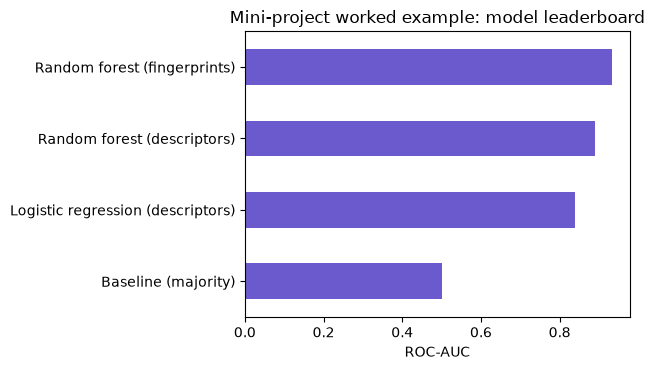

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
board["ROC_AUC"][::-1].plot.barh(ax=ax, color="slateblue")
ax.set_xlabel("ROC-AUC"); ax.set_title("Mini-project worked example: model leaderboard")
fig.tight_layout(); fig.savefig(FIGDIR / "mini_project_worked_leaderboard.png", dpi=200)
plt.show()


### ✅ Check yourself — Section 3

Prints `Section 3 OK`. Every real model beats the baseline; a leaderboard figure is saved.


In [9]:
# --- checkpoint (do not edit) ---
assert len(board) == 4
assert board.iloc[0]["ROC_AUC"] > results["Baseline (majority)"]["ROC_AUC"]
assert (FIGDIR / "mini_project_worked_leaderboard.png").is_file()
print("Section 3 OK")


Section 3 OK


**Conceptual questions**


1. Unlike the ESOL regression examples all through this course, the
   fingerprint representation may well **beat** descriptors here for BBBP
   classification. What does that tell you about generalising a "which
   representation wins" finding from one task to another?


**Answers**


1. It confirms Week 06's point directly: representation performance is
   dataset- and task-dependent, not a fixed hierarchy — ESOL's descriptors
   winning does not predict BBBP's outcome, and neither should be assumed to
   hold for your own mini-project's dataset without actually checking, which
   is exactly why this checklist item exists.


---
## 4. Two evaluation splits ✅ *(checklist item 4)*

Random split (Section 3) vs a Butina cluster split (Week 02B/03B/04) for the
same model — do they agree?


In [10]:
def tanimoto_distance_matrix(fp_list):
    dists = []
    for i in range(1, len(fp_list)):
        sims = DataStructs.BulkTanimotoSimilarity(fp_list[i], fp_list[:i])
        dists.extend(1.0 - s for s in sims)
    return dists

def cluster_split(clusters, n_total, test_frac=0.2, seed=0):
    rng = np.random.default_rng(seed)
    order = list(range(len(clusters))); rng.shuffle(order)
    test_mask = np.zeros(n_total, dtype=bool)
    target = int(np.ceil(test_frac * n_total))
    for c in order:
        if test_mask.sum() >= target:
            break
        for i in clusters[c]:
            test_mask[i] = True
    return ~test_mask, test_mask

dmat = tanimoto_distance_matrix(fps)
clusters = Butina.ClusterData(dmat, len(fps), 0.4, isDistData=True)
clusters = sorted(clusters, key=len, reverse=True)
train_mask, test_mask = cluster_split(clusters, len(mols), test_frac=0.2, seed=0)

rf_cluster = RandomForestClassifier(n_estimators=300, random_state=0,
                                    class_weight="balanced", n_jobs=-1)
rf_cluster.fit(Xdesc[train_mask], y[train_mask])
cluster_auc = roc_auc_score(y[test_mask], rf_cluster.predict_proba(Xdesc[test_mask])[:, 1])

print(f"random-split  RF/descriptors ROC-AUC: {results['Random forest (descriptors)']['ROC_AUC']:.3f}")
print(f"cluster-split RF/descriptors ROC-AUC: {cluster_auc:.3f}")


random-split  RF/descriptors ROC-AUC: 0.889
cluster-split RF/descriptors ROC-AUC: 0.821


### ✅ Check yourself — Section 4

Prints `Section 4 OK`. A cluster-split AUC is reported alongside the random-split one.


In [11]:
# --- checkpoint (do not edit) ---
assert 0.5 < cluster_auc <= 1.0
print("Section 4 OK")


Section 4 OK


**Conceptual questions**


1. If the two splits gave *very* similar scores here, would that mean the
   cluster split was unnecessary to check?


**Answers**


1. No — checking and finding agreement is itself informative (it suggests
   this particular model/representation is not relying heavily on
   near-duplicate leakage), which is a genuinely different, and equally
   valid, outcome from checking and finding a gap; the point of the checklist
   item is to *look*, not to expect a particular answer.


---
## 5. Error analysis ✅ *(checklist item 5)*

Structures, not just a confusion matrix (Week 04B) — for the random-split
`Random forest (descriptors)` model.


confusion matrix [rows=true 0/1, cols=pred 0/1]:
 [[ 68  26]
 [ 34 266]]
34 false negatives (permeable compounds predicted non-permeable)


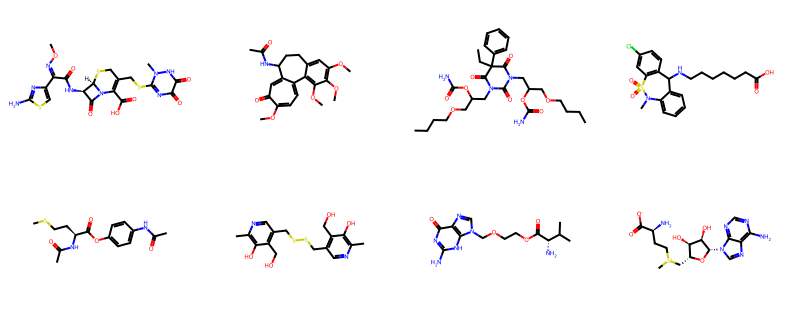

In [12]:
pred_desc = rf_desc.predict(Xdesc[idx_test])
cm = confusion_matrix(y_test, pred_desc)
print("confusion matrix [rows=true 0/1, cols=pred 0/1]:\n", cm)

false_negative_idx = idx_test[(pred_desc == 0) & (y_test == 1)]
fn_smiles = bbbp["canonical_smiles"].iloc[false_negative_idx].tolist()
print(f"{len(fn_smiles)} false negatives (permeable compounds predicted non-permeable)")

fn_mols = [Chem.MolFromSmiles(s) for s in fn_smiles[:8]]
grid = Draw.MolsToGridImage(fn_mols, molsPerRow=4, subImgSize=(200, 160), returnPNG=False)
grid.save(FIGDIR / "mini_project_error_analysis.png")
grid


### ✅ Check yourself — Section 5

Prints `Section 5 OK`. A grid of false-negative structures is saved.


In [13]:
# --- checkpoint (do not edit) ---
assert cm.sum() == len(y_test)
assert (FIGDIR / "mini_project_error_analysis.png").is_file()
print("Section 5 OK")


Section 5 OK


**Conceptual questions**


1. Why draw the false negatives as *structures* rather than just reporting
   their count?


**Answers**


1. A count tells you *how much* the model misses; structures let you form a
   hypothesis about *why* (shared scaffolds, unusual functional groups,
   borderline size/polarity) — exactly the difference between quoting a
   metric and actually understanding a model's failure mode (Week 04B).


---
## 6. A stated limitation ✅ *(checklist item 6)*

**Written directly, as the mini-project brief requires — not left implicit:**

This worked example's models are trained on a public, historically-curated
dataset (BBBP) whose labelling methodology and era are not audited here;
class imbalance (~76%/24%) means the random-split leaderboard's headline
ROC-AUC numbers should always be read alongside the per-class recall figures
from Week 04A, not in isolation. The fingerprint representation outperforming
descriptors here should **not** be generalised to other tasks (Section 3) —
Week 06's representation-shootout lesson applies to every new dataset
independently. Finally, the desalting heuristic (Section 1: "keep the
largest fragment") is a reasonable default but can occasionally be wrong for
genuinely co-crystallised or multi-component active pharmaceutical
ingredients; a production study would need to audit a sample of desalted
rows by hand.

**Reproducibility** ✅ *(checklist item 7)*: one fixed seed (`SEED`) is
declared once at the top of this notebook and used everywhere a random
process occurs; the environment is `env/environment.yml`, unchanged from the
rest of the course.


---
## 7. Exercises

These check that the checklist was actually followed correctly — the same
kind of self-audit your own mini-project notebook should be able to pass.


### Exercise 1 — verify the reproducibility checklist item *(easy, ~10 min)*

Write `check_reproducible(fit_fn, n_repeats=3)` that calls a zero-argument
`fit_fn` (which must internally use the fixed `SEED`) `n_repeats` times and
returns `True` only if every call produces an **identical** result.

<details><summary>Show hint</summary>

Wrap `RandomForestClassifier(random_state=0, ...).fit(...).predict(...)` in
`fit_fn`; compare each repeat's predictions with `np.array_equal`.
</details>


In [14]:
def check_reproducible(fit_fn, n_repeats=3):
    """True if fit_fn() returns an identical array every time it is called."""
    results = [fit_fn() for _ in range(n_repeats)]
    return all(np.array_equal(results[0], r) for r in results[1:])

def _fit_and_predict():
    model = RandomForestClassifier(n_estimators=50, random_state=0, n_jobs=-1)
    model.fit(Xdesc[idx_train], y_train)
    return model.predict(Xdesc[idx_test])

print("reproducible?", check_reproducible(_fit_and_predict))


reproducible? True


In [15]:
# --- check your answer (do not edit) ---
assert check_reproducible(_fit_and_predict) is True
def _not_reproducible():
    return np.random.default_rng().integers(0, 1000, size=5)
assert check_reproducible(_not_reproducible) is False
print("Exercise 1 OK")


Exercise 1 OK


### Exercise 2 — verify no leakage between the two splits' test sets *(medium, ~12 min)*

Write `splits_are_independent(idx_test, test_mask)` checking that the
**identity** of "random-split test molecules" and "cluster-split test
molecules" need not (and generally will not) match, but that **within**
each split, train and test never overlap. Return a dict of the three
booleans checked.

<details><summary>Show hint</summary>

`set(idx_test).isdisjoint(set(idx_train))` for the random split;
`(train_mask & test_mask).any()` should be `False` for the cluster split.
</details>


In [16]:
def splits_are_independent(idx_train, idx_test, train_mask, test_mask):
    """Sanity-check both splits are internally disjoint."""
    return {
        "random_split_disjoint": set(idx_train).isdisjoint(set(idx_test)),
        "cluster_split_disjoint": not (train_mask & test_mask).any(),
    }

checks = splits_are_independent(idx_train, idx_test, train_mask, test_mask)
print(checks)


{'random_split_disjoint': True, 'cluster_split_disjoint': True}


In [17]:
# --- check your answer (do not edit) ---
assert checks["random_split_disjoint"] is True
assert checks["cluster_split_disjoint"] is True
print("Exercise 2 OK")


Exercise 2 OK


### Exercise 3 — a false-positive counterpart to Section 5 *(medium, ~12 min)*

Section 5 examined false negatives only. Write `false_positive_smiles(model,
X, idx_test, y_test)` returning the canonical SMILES of every false positive
(predicted permeable, actually not).

<details><summary>Show hint</summary>

Mirror Section 5's false-negative code with the prediction/label roles
swapped.
</details>


In [18]:
def false_positive_smiles(model, X, idx_test, y_test):
    """Canonical SMILES of every false positive for `model` on the test set."""
    pred = model.predict(X[idx_test])
    fp_idx = idx_test[(pred == 1) & (y_test == 0)]
    return bbbp["canonical_smiles"].iloc[fp_idx].tolist()

fp_smiles = false_positive_smiles(rf_desc, Xdesc, idx_test, y_test)
print(f"{len(fp_smiles)} false positives")


26 false positives


In [19]:
# --- check your answer (do not edit) ---
assert isinstance(fp_smiles, list)
assert all(Chem.MolFromSmiles(s) is not None for s in fp_smiles)
print("Exercise 3 OK")


Exercise 3 OK


### 🏁 Mini-challenge — assemble the whole checklist into one function

Write `run_mini_project_checklist(raw_df, smiles_col, target_col)` that
performs Sections 1-4 (hygiene, both representations, baseline+RF, both
splits) on **any** dataframe with a SMILES column and a binary target
column, returning a dict summarising every checklist item's result. This is
the kind of reusable function worth building for your **own** mini-project.


Implement `run_mini_project_checklist` below and run it on `raw` (BBBP) to
confirm it reproduces Section 3's random-split leaderboard numbers.


In [20]:
def run_mini_project_checklist(raw_df, smiles_col, target_col, seed=SEED):
    """Run the hygiene -> representations -> baseline+RF -> two-split pipeline."""
    df = raw_df.copy()
    df["canonical_smiles"] = df[smiles_col].apply(largest_fragment_smiles)
    df = df[df["canonical_smiles"].notna()].drop_duplicates("canonical_smiles").reset_index(drop=True)

    mols_ = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    X_ = np.array([[fn(m) for fn in DESCRIPTORS.values()] for m in mols_], dtype=float)
    y_ = df[target_col].to_numpy()

    idx_ = np.arange(len(mols_))
    tr_, te_ = train_test_split(idx_, test_size=0.2, random_state=42, stratify=y_)

    dummy = DummyClassifier(strategy="most_frequent").fit(X_[tr_], y_[tr_])
    baseline_auc = roc_auc_score(y_[te_], dummy.predict_proba(X_[te_])[:, 1])

    model = RandomForestClassifier(n_estimators=300, random_state=0, class_weight="balanced", n_jobs=-1)
    model.fit(X_[tr_], y_[tr_])
    prob_ = model.predict_proba(X_[te_])[:, 1]

    return {
        "n_molecules": len(df),
        "class_balance": float(y_.mean()),
        "baseline_auc": baseline_auc,
        "model_auc": roc_auc_score(y_[te_], prob_),
    }

summary = run_mini_project_checklist(raw, "smiles", "p_np")
print(summary)


{'n_molecules': 1966, 'class_balance': 0.7609359104781281, 'baseline_auc': 0.5, 'model_auc': 0.889450354609929}


In [21]:
# --- check your answer (do not edit) ---
assert summary["n_molecules"] == n2
assert summary["model_auc"] > summary["baseline_auc"]
print("Mini-challenge OK")


Mini-challenge OK


---
## Summary — what this session showed

Every required mini-project element, applied together on one dataset:

1. Data hygiene (desalting, dedup) — Weeks 02B, 04A.
2. Two representations (descriptors, fingerprints) — Weeks 02, 02B.
3. A baseline plus at least two real models — Weeks 03B, 04.
4. A random split *and* a structure-aware split — Weeks 02B, 03B, 04.
5. Metrics appropriate to a classification task under imbalance — Weeks
   03A, 04.
6. Error analysis as structures, not just a confusion matrix — Week 04B.
7. A stated limitation and explicit reproducibility note — this session.

The rest of this session is your own mini-project. Use this notebook as a
structural reference, `assessments/mini-project-brief.md` as the rubric, and
every earlier week's notebook as the technique library. Good luck —
presentations are the rest of this session.


## Further reading

- `assessments/mini-project-brief.md` — the rubric this session's checklist
  is drawn from.
- Every previous week's "Further reading" section, as relevant to your own
  chosen dataset and task.


## Attribution

This notebook assembles techniques already attributed in their originating
weeks (see Weeks 02, 02B, 03B, 04A, 04B's own Attribution cells for the
sources each technique is adapted from). No new external material is
introduced this session.
